# Generate Melt Dates Using In Situ Data

This code generates melt dates (MOD and MED) for intercomparison using in situ observations.  
Air temperature data are obtained from the Global Surface Summary of the Day (GSOD), while snow water equivalent (SWE) is derived from the Northern Hemisphere Snow Water Equivalent (NH-SWE) dataset. It should be noted that the SWE data are not direct observations; instead, they are estimated from observed snow depth using a modeling approach, due to the difficulty of directly measuring SWE.
To ensure data reliability, melt dates are calculated only for pixels and years where both air temperature and SWE data are simultaneously available for at least 80% of the days.

In [1]:
import sys
import os
import platform
import importlib
import math
import glob
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import calendar
import netCDF4 as nc
import xarray as xr
from datetime import timedelta
import datetime
from dateutil.relativedelta import relativedelta
from scipy.interpolate import griddata
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyproj import Proj, transform
import cartopy.feature as cfeature
import matplotlib.colors as colors
import matplotlib.path as mpath
import rioxarray
import rasterio
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm
import geopandas as gpd
from shapely.geometry import Point

if platform.system() == 'Darwin':  # macOS
    base_FP = '/home/nayoung/data'
    cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    nas_data_FP = '/home/nayoung/nas_data'
    data2_FP = '/home/nayoung/data_2'
else:
    base_FP = '/home/nayoung/data'
    cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    nas_data_FP = '/home/nayoung/nas_data'
    data2_FP = '/home/nayoung/data_2'
sys.path.append(base_FP + '/python_modules')

# HydroAI libs
import HydroAI.Data as hData
import HydroAI.Plot as hPlot
import HydroAI.Grid as hGrid
import HydroAI.Land_Properties as hLP
importlib.reload(hData);
importlib.reload(hPlot);
importlib.reload(hGrid);
importlib.reload(hLP);

# Ignore runtime warnings
import warnings
warnings.filterwarnings("ignore")


## Define functions to plot for the north of 60°N

In [2]:
def plot_Northpole(domain_lon, domain_lat, data, label_title, cmap,
                   vmin=-1, vmax=1, vcenter=0, bounds=None, ticks=None, ticklabels=None):

    fig = plt.figure(figsize=(10, 10))
    ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=0))

    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)

    ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.OCEAN, facecolor='powderblue', zorder=0)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)

    masked_data = np.ma.masked_invalid(data)

    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(alpha=0)

    # Continuous/Discrete norm
    if bounds is None:
        if vcenter is None:
            norm = colors.Normalize(vmin=vmin, vmax=vmax)
        else:
            norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

    else:
        norm = colors.BoundaryNorm(bounds, ncolors=cmap_obj.N, clip=True)

    mesh = ax.pcolormesh(
        domain_lon, domain_lat, masked_data,
        transform=ccrs.PlateCarree(),
        cmap=cmap_obj,
        norm=norm,
        zorder=2,
        shading="auto"
    )

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='gray', alpha=0.5, linestyle='--', zorder=4)
                
    gl.xlabel_style = {'size': 18}
    gl.ylabel_style = {'size': 18}

    gl.top_labels = False
    gl.right_labels = False

    cbar = plt.colorbar(
        mesh, ax=ax, orientation='horizontal',
        pad=0.07, shrink=0.8, extend='neither',
        boundaries=bounds if bounds is not None else None,
        ticks=ticks
    )
    cbar.set_label(label_title, fontsize=12, labelpad=10)
    cbar.ax.tick_params(labelsize=18)

    if ticklabels is not None:
        cbar.set_ticklabels(ticklabels)
    elif bounds is None:
        tick_values = np.linspace(vmin, vmax, 5)
        cbar.set_ticks(tick_values)
        cbar.set_ticklabels([f'{v:.2f}' for v in tick_values])

    plt.title(label_title, fontsize=16, pad=20)
    plt.show()

    return fig, ax

In [3]:
# Function for plotting the stations north of 60°N
def plot_Northpole_stations_with_coords(
    pts_all, pts_highlight=None,
    title="Stations",
    north_of=60.0,
    s_all=5, s_high=8,
    c_all="yellow", c_high="red",
    label_all=None, label_high=None,
    lon_col="lon_w", lat_col="lat",
    lon_grid_interval=60,
    lat_grid_interval=5,
    draw_grid_labels=True
):

    fig = plt.figure(figsize=(10, 10))
    ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=0))

    # Circular boundary
    theta = np.linspace(0, 2 * np.pi, 200)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)

    ax.set_extent([-180, 180, north_of, 90], crs=ccrs.PlateCarree())

    # Background
    ax.add_feature(cfeature.OCEAN, facecolor="powderblue", zorder=0)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor="black", zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)

    # Gridlines
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=draw_grid_labels,
        linewidth=1,
        color="gray",
        alpha=0.5,
        linestyle="--",
        xlocs=np.arange(-180, 181, lon_grid_interval),
        ylocs=np.arange(north_of, 91, lat_grid_interval),
        zorder=4
    )

    if draw_grid_labels:
        gl.top_labels = True
        gl.bottom_labels = True
        gl.left_labels = True
        gl.right_labels = False
        gl.xlabel_style = {"size": 25, "color": "black"}
        gl.ylabel_style = {"size": 25, "color": "black"}

    # Default labels
    if label_all is None:
        label_all = f"All stations (n={len(pts_all)})"

    # All stations
    ax.scatter(
        pts_all[lon_col].values,
        pts_all[lat_col].values,
        s=s_all,
        c=c_all,
        transform=ccrs.PlateCarree(),
        zorder=5,
        label=label_all
    )

    # Highlighted stations
    if pts_highlight is not None and len(pts_highlight) > 0:
        if label_high is None:
            label_high = f"Highlighted (n={len(pts_highlight)})"

        ax.scatter(
            pts_highlight[lon_col].values,
            pts_highlight[lat_col].values,
            s=s_high,
            c=c_high,
            transform=ccrs.PlateCarree(),
            zorder=6,
            label=label_high
        )

    plt.title(title, fontsize=16, pad=20)
    # ax.legend(loc="lower left", frameon=True)

    plt.show()
    return fig, ax

## Selection of Valid Station Pairs Based on Data Availability and Quality Control

This section identifies valid GSOD–NH SWE station pairs for melt date estimation. For each year, air temperature ($T_{\mathrm{air}}$) from GSOD and SWE from the NH-SWE dataset are matched based on spatial proximity (rounded coordinates). Only station pairs located north of 60°N are considered. A station pair is retained only if both SWE and $T_{\mathrm{air}}$ are simultaneously available (i.e., finite values) for at least 80% of the days within the year.

Additional quality control is applied to exclude unreliable records. A station pair is removed if it meets any of the following conditions:

1. Ten or more days with SWE equal to zero occur within DOY 1–30.  
2. The annual maximum SWE is less than or equal to 50 mm.  

For the remaining valid station pairs, the matched time series of SWE and air temperature, along with station metadata, are stored for further analysis.

In [4]:
# Define a function to check if a year is a leap year
def is_leap(year: int) -> bool:
    return (year % 4 == 0) and ((year % 100 != 0) or (year % 400 == 0))

# Define the start and end year
start_year = 1988
end_year = 2022

for year in range(start_year, end_year + 1):
    print(f"Processing year: {year}")
    
    NH_SWE_meta_filepath = os.path.join(cpuserver_data_FP, f'personal_data/project_snow/NH_SWE/NH_SWE_METADATA.csv')
    NH_SWE_filepath = os.path.join(cpuserver_data_FP, f'personal_data/project_snow/NH_SWE/files') # File names are like NH_SWE_ID_(station number).csv
    GSOD_Tair_filepath = os.path.join(nas_data_FP, f'GSOD') # File names are like GSOD_lat_lon_(station number)-99999_1988-2022.csv

    ## 1. Select NH-SWE stations with latitude ≥ 60°N
    metadata_csv = pd.read_csv(NH_SWE_meta_filepath)
    metadata_csv['NHSWEID'] = pd.to_numeric(metadata_csv['NHSWEID'], errors='coerce').astype('Int64')
    metadata_csv['LAT'] = pd.to_numeric(metadata_csv['LAT'], errors='coerce')
    metadata_csv['LON'] = pd.to_numeric(metadata_csv['LON'], errors='coerce')
    metadata_sel = metadata_csv[metadata_csv['LAT'] >= 60].copy().reset_index(drop=True)

    # Prepare the matching key (lon_r, lat_r) -> original coordinates/ID
    metadata_sel['lat_r'] = metadata_sel['LAT'].round(1)
    metadata_sel['lon_r'] = metadata_sel['LON'].round(1)

    nhswe_key_to_info = {}
    for _, row in metadata_sel.iterrows():
        # If there are multiple same keys, the last one will be kept, but it will be filtered out by the file existence criteria below
        nhswe_key_to_info[(float(row['lon_r']), float(row['lat_r']))] = {
            'lat': float(row['LAT']),
            'lon': float(row['LON']),
            'id':  int(row['NHSWEID'])
        }

    print(f"NH-SWE candidates north of 60°N: {len(metadata_sel)}")

    # List of reference locations (rounded)
    nhswe_locations = list(zip(metadata_sel['lon_r'].astype(float), metadata_sel['lat_r'].astype(float)))
    print(nhswe_locations[:10], '...')  # Preview

    ## 2. Match GSOD and NH-SWE stations by coordinates and retain pairs with ≥80% of days having both SWE and T_air available
    merged_records = []

    # Calculate the threshold number of days (leap year handling)
    days_in_year = 366 if pd.Timestamp(year=year, month=12, day=31).is_leap_year else 365
    threshold_days = int(np.floor(0.8 * days_in_year))

    for file in os.listdir(GSOD_Tair_filepath):
        if not file.endswith('.csv'):
            continue

        parts = file.split('_')
        if len(parts) < 4:
            continue

        # GSOD file name is like GSOD_lat_lon_(station number)-99999_1988-2022.csv
        try:
            gsod_lat = float(parts[1]) # Extract latitude from the file name
            gsod_lon = float(parts[2]) # Extract longitude from the file name
        except ValueError:
            continue

        gsod_station_number = parts[3].split('.')[0]  # '12345-99999'

        # Match the coordinates with NH-SWE (rounded to 1 decimal place)
        key = (round(gsod_lon, 1), round(gsod_lat, 1))
        if key not in nhswe_key_to_info:
            continue

        nh_info = nhswe_key_to_info[key]
        nh_id   = nh_info['id']
        nh_lat  = nh_info['lat']
        nh_lon  = nh_info['lon']

        # Find the NH-SWE file (_{id}.csv)
        nhswe_file = None
        for f in os.listdir(NH_SWE_filepath):
            if f.endswith(f'_{nh_id}.csv'):
                nhswe_file = os.path.join(NH_SWE_filepath, f)
                break
        if nhswe_file is None:
            continue  # If the file is not found, skip

        # Load and preprocess the files
        # NH-SWE
        df_n = pd.read_csv(nhswe_file)
        df_n['Date'] = pd.to_datetime(df_n['Date'], errors='coerce')
        df_n['SWE (mm)'] = pd.to_numeric(df_n['SWE (mm)'], errors='coerce')
        df_n = df_n[df_n['Date'].dt.year == year].copy()
        if df_n.empty:
            continue
        df_n['Date'] = df_n['Date'].dt.normalize()

        # GSOD
        gsod_path = os.path.join(GSOD_Tair_filepath, file)
        df_g = pd.read_csv(gsod_path)
        df_g['DATE'] = pd.to_datetime(df_g['DATE'], errors='coerce')
        df_g['TEMP'] = pd.to_numeric(df_g['TEMP'], errors='coerce')
        df_g['TEMP'] = (df_g['TEMP'] - 32) * 5/9  # F -> C
        df_g = df_g[df_g['DATE'].dt.year == year].copy()
        if df_g.empty:
            continue
        df_g['DATE'] = df_g['DATE'].dt.normalize()

        # Merge SWE and T_air data
        df_m = pd.merge(
            df_n[['Date', 'SWE (mm)']],
            df_g[['DATE', 'TEMP']],
            left_on='Date', right_on='DATE', how='inner'
        )
        if df_m.empty:
            continue

        # Count the valid days
        valid_mask = np.isfinite(df_m['SWE (mm)']) & np.isfinite(df_m['TEMP'])
        valid_days = int(valid_mask.sum())

        if valid_days >= threshold_days:
            use = df_m[['Date', 'SWE (mm)', 'TEMP']].copy()
            use.loc[~valid_mask, ['SWE (mm)', 'TEMP']] = np.nan
            
            # Quality control
            use["DOY"] = use["Date"].dt.dayofyear
            # SWE zero days in DOY 1–30 
            early = use[(use["DOY"] <= 30) & np.isfinite(use["SWE (mm)"])]
            n_zero = (early["SWE (mm)"] == 0).sum()

            if n_zero >= 10:
                continue

            # Annual SWE max 
            SWE_max = np.nanmax(use["SWE (mm)"])

            if SWE_max <= 50:
                continue
            

            out = pd.DataFrame({
                'date': use['Date'],
                'original_NHSWE_lat':  nh_lat,
                'original_NHSWE_lon':  nh_lon,
                'NHSWE_station_number': nh_id,
                'original_GSOD_lat':   gsod_lat,
                'original_GSOD_lon':   gsod_lon,
                'GSOD_station_number': gsod_station_number,
                'SWE':                 use['SWE (mm)'].values,
                'Tair (degrees celsius)': use['TEMP'].values,
            })

            merged_records.append(out)


    # Save the results
    save_dir = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Insitu/GSOD_overlap'
    os.makedirs(save_dir, exist_ok=True)
    if merged_records:
        merged_df = pd.concat(merged_records, ignore_index=True)
        out_path = os.path.join(save_dir, f'NH_SWE_GSOD_overlap_{year}.csv')
        merged_df.to_csv(out_path, index=False)
        print(f'Saved: {out_path} (rows={len(merged_df)})')
    else:
        print('No valid NH-SWE × GSOD pairs found.')
        merged_df = pd.DataFrame(columns=[
            'date','original_NHSWE_lat','original_NHSWE_lon','NHSWE_station_number',
            'original_GSOD_lat','original_GSOD_lon','GSOD_station_number','SWE','Tair (degrees celsius)'
        ])



Processing year: 1988
NH-SWE candidates north of 60°N: 2459
[(15.6, 60.6), (17.2, 65.1), (14.5, 63.2), (59.4, 67.1), (34.8, 65.0), (53.0, 67.6), (14.8, 68.8), (19.0, 74.5), (11.1, 63.2), (11.6, 60.4)] ...
Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/Insitu/GSOD_overlap/NH_SWE_GSOD_overlap_1988.csv (rows=62274)
Processing year: 1989
NH-SWE candidates north of 60°N: 2459
[(15.6, 60.6), (17.2, 65.1), (14.5, 63.2), (59.4, 67.1), (34.8, 65.0), (53.0, 67.6), (14.8, 68.8), (19.0, 74.5), (11.1, 63.2), (11.6, 60.4)] ...
Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/Insitu/GSOD_overlap/NH_SWE_GSOD_overlap_1989.csv (rows=64234)
Processing year: 1990
NH-SWE candidates north of 60°N: 2459
[(15.6, 60.6), (17.2, 65.1), (14.5, 63.2), (59.4, 67.1), (34.8, 65.0), (53.0, 67.6), (14.8, 68.8), (19.0, 74.5), (11.1, 63.2), (11.6, 60.4)] ...
Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensur

## Combine Yearly Overlap Files and Identify Station Pairs

This section reads all yearly overlap files and combines them into a single dataset.  
The resulting dataset is used to identify unique GSOD–NH SWE station pairs over the full 35-year period (1988–2022).

In [5]:
save_dir = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Insitu/GSOD_overlap"

# Define the start and end year
start_year, end_year = 1988, 2022

# Load and merge yearly overlap files
dfs = []
for year in range(start_year, end_year + 1):
    fp = os.path.join(save_dir, f"NH_SWE_GSOD_overlap_{year}.csv")
    if not os.path.exists(fp):
        continue

    df = pd.read_csv(fp)
    if df.empty:
        continue

    # Add year column
    df["year"] = year

    # Parse date
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    dfs.append(df)

if not dfs:
    print("No valid overlap CSVs found.")
    all_out = pd.DataFrame()
else:
    all_out = pd.concat(dfs, ignore_index=True)

    # Only north of 60N
    all_out = all_out[all_out["original_GSOD_lat"] >= 60].copy()

    keep_cols = [
        "date",
        "original_NHSWE_lat", "original_NHSWE_lon", "NHSWE_station_number",
        "original_GSOD_lat", "original_GSOD_lon", "GSOD_station_number",
        "SWE", "Tair (degrees celsius)",
        "year",
    ]
    all_out = all_out[keep_cols].sort_values(["NHSWE_station_number", "GSOD_station_number", "date"])

    print("All valid station-pair time series rows:", len(all_out))
    print("Number of unique NH-SWE stations (1988–2022):", all_out["NHSWE_station_number"].nunique())
    print("Number of unique GSOD stations (1988–2022):", all_out["GSOD_station_number"].nunique())
    print("Number of unique station pairs (1988–2022):", all_out.drop_duplicates(["NHSWE_station_number","GSOD_station_number"]).shape[0])


# Count unique station pairs per year
pairs_per_year = (
    all_out
    .drop_duplicates(["year", "NHSWE_station_number", "GSOD_station_number"])
    .groupby("year")
    .size()
    .reset_index(name="n_pairs")
    .sort_values("year")
)
print("Sum of yearly unique station pairs:", sum(pairs_per_year["n_pairs"]))

# Count total unique pairs
total_unique_pairs = (
    all_out
    .drop_duplicates(["NHSWE_station_number", "GSOD_station_number"])
    .shape[0]
)
print("Total unique station pairs without duplicates (1988-2022):", total_unique_pairs)


# Save 
out_path = os.path.join(save_dir, f"NH_SWE_GSOD_overlap_ALL_{start_year}_{end_year}.csv")
all_out.to_csv(out_path, index=False)
print("Saved:", out_path)


All valid station-pair time series rows: 1951254
Number of unique NH-SWE stations (1988–2022): 432
Number of unique GSOD stations (1988–2022): 489
Number of unique station pairs (1988–2022): 489
Sum of yearly unique station pairs: 5446
Total unique station pairs without duplicates (1988-2022): 489
Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/Insitu/GSOD_overlap/NH_SWE_GSOD_overlap_ALL_1988_2022.csv


## Distribution of Stations by Continent

This section examines the spatial distribution of stations across continents.  
To assign each station to a continent, a shapefile from GADM version 4.1 was used.
GADM 4.1 provides a high-resolution global spatial database containing boundaries of countries and their subnational administrative units. In GADM, higher numeric levels correspond to more detailed administrative units. Here, only level 0 (country-level boundaries) was used.

In [ ]:
# Extract unique station pairs and their representative NH-SWE coordinates
stations = (
    all_out
    .drop_duplicates(["NHSWE_station_number", "GSOD_station_number"])
    [["original_NHSWE_lat", "original_NHSWE_lon",
      "NHSWE_station_number", "GSOD_station_number"]]
    .copy()
)

# Create point geometries from station coordinates
stations["geometry"] = stations.apply(
    lambda row: Point(row["original_NHSWE_lon"], row["original_NHSWE_lat"]),
    axis=1
)

gdf_stations = gpd.GeoDataFrame(stations, geometry="geometry", crs="EPSG:4326")
print("Station GeoDataFrame created:", len(gdf_stations))


root = "/home/nayoung/cpuserver_data/python_modules/Nayoung/Nation_shp_files"

# 1. Load all *_0.shp under subfolders 
shp_files = glob.glob(os.path.join(root, "**", "*_0.shp"), recursive=True)
shp_files = [p for p in shp_files if not os.path.basename(p).startswith("._")]

print("Found _0 shapefiles:", len(shp_files))
print("\n".join(shp_files))


# 2. Read and merge shapefiles while retaining only the required columns
gdfs = []
for p in shp_files:
    g = gpd.read_file(p)
    # Harmonize CRS to EPSG:4326
    if g.crs is None:
        g = g.set_crs("EPSG:4326")
    else:
        g = g.to_crs("EPSG:4326")

    # GADM 4.1 typically provides NAME_0 and GID_0
    keep = [c for c in ["NAME_0", "GID_0", "geometry"] if c in g.columns]
    g = g[keep].copy()

    # If GID_0 is missing, infer ISO3 from folder name like gadm41_CAN_shp
    if "GID_0" not in g.columns:
        iso3 = os.path.basename(os.path.dirname(p)).split("_")[1]  # CAN, USA, ...
        g["GID_0"] = iso3
    if "NAME_0" not in g.columns:
        g["NAME_0"] = g["GID_0"]

    gdfs.append(g)

countries = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs="EPSG:4326")
countries["iso3"] = countries["GID_0"].astype(str).str[:3]  

print("Countries features:", len(countries))
print("iso3 in shp:", sorted(countries["iso3"].unique()))


# 3. Spatially join each station pair to its corresponding country polygon
gdf_stations = gdf_stations.to_crs("EPSG:4326")

joined = gpd.sjoin(
    gdf_stations,
    countries[["iso3", "NAME_0", "geometry"]],
    how="left",
    predicate="within"
)

print("Unmatched stations:", joined["iso3"].isna().sum())


# 4. Make the custom region groups
def region_group(iso3):
    if pd.isna(iso3):
        return "Unmatched"
    if iso3 in ["USA", "CAN"]:
        return "North America"
    if iso3 in ["NOR", "SWE", "FIN", "SJM"]:   # SJM (Svalbard&JanMayen) 
        return "Scandinavia"
    if iso3 == "RUS":
        return "Russia"
    if iso3 == "ISL":
        return "Iceland"
    if iso3 == "GRL":
        return "Greenland"
    return "Other"

joined["region_group"] = joined["iso3"].apply(region_group)


# 5. Count stations by region and country on a unique station-pair basis
counts_region = joined["region_group"].value_counts()
counts_country = joined["iso3"].value_counts()
region_table = counts_region.rename_axis("Region").reset_index(name="Count")
country_table = counts_country.rename_axis("ISO3").reset_index(name="Count")

print("\nRegion summary:")
display(region_table)

print("\nCountry summary:")
display(country_table)


Station GeoDataFrame created: 489
Found _0 shapefiles: 9
/home/nayoung/cpuserver_data/python_modules/Nayoung/Nation_shp_files/gadm41_CAN_shp/gadm41_CAN_0.shp
/home/nayoung/cpuserver_data/python_modules/Nayoung/Nation_shp_files/gadm41_SJM_shp/gadm41_SJM_0.shp
/home/nayoung/cpuserver_data/python_modules/Nayoung/Nation_shp_files/gadm41_GRL_shp/gadm41_GRL_0.shp
/home/nayoung/cpuserver_data/python_modules/Nayoung/Nation_shp_files/gadm41_ISL_shp/gadm41_ISL_0.shp
/home/nayoung/cpuserver_data/python_modules/Nayoung/Nation_shp_files/gadm41_FIN_shp/gadm41_FIN_0.shp
/home/nayoung/cpuserver_data/python_modules/Nayoung/Nation_shp_files/gadm41_NOR_shp/gadm41_NOR_0.shp
/home/nayoung/cpuserver_data/python_modules/Nayoung/Nation_shp_files/gadm41_SWE_shp/gadm41_SWE_0.shp
/home/nayoung/cpuserver_data/python_modules/Nayoung/Nation_shp_files/gadm41_RUS_shp/gadm41_RUS_0.shp
/home/nayoung/cpuserver_data/python_modules/Nayoung/Nation_shp_files/gadm41_USA_shp/gadm41_USA_0.shp
Countries features: 9
iso3 in shp:

,Region,Count
0,Scandinavia,239
1,Russia,113
2,North America,102
3,Unmatched,33
4,Iceland,2



Country summary:


,ISO3,Count
0,RUS,113
1,FIN,111
2,NOR,72
3,CAN,55
4,SWE,53
5,USA,47
6,SJM,3
7,ISL,2


## Spatial Distribution of Valid NH-SWE Stations

This section plots the NH-SWE stations that formed at least one valid GSOD–NH-SWE pair during the 35-year period (1988–2022).

Rather than displaying all matched station pairs, which would make the figure visually cluttered, only the NH-SWE station locations are plotted. The resulting map therefore shows the distribution of NH-SWE stations that were retained for intercomparison after applying the pairing, data availability, and quality control criteria.

### Figure 11b

Number of unique NH-SWE stations: 432


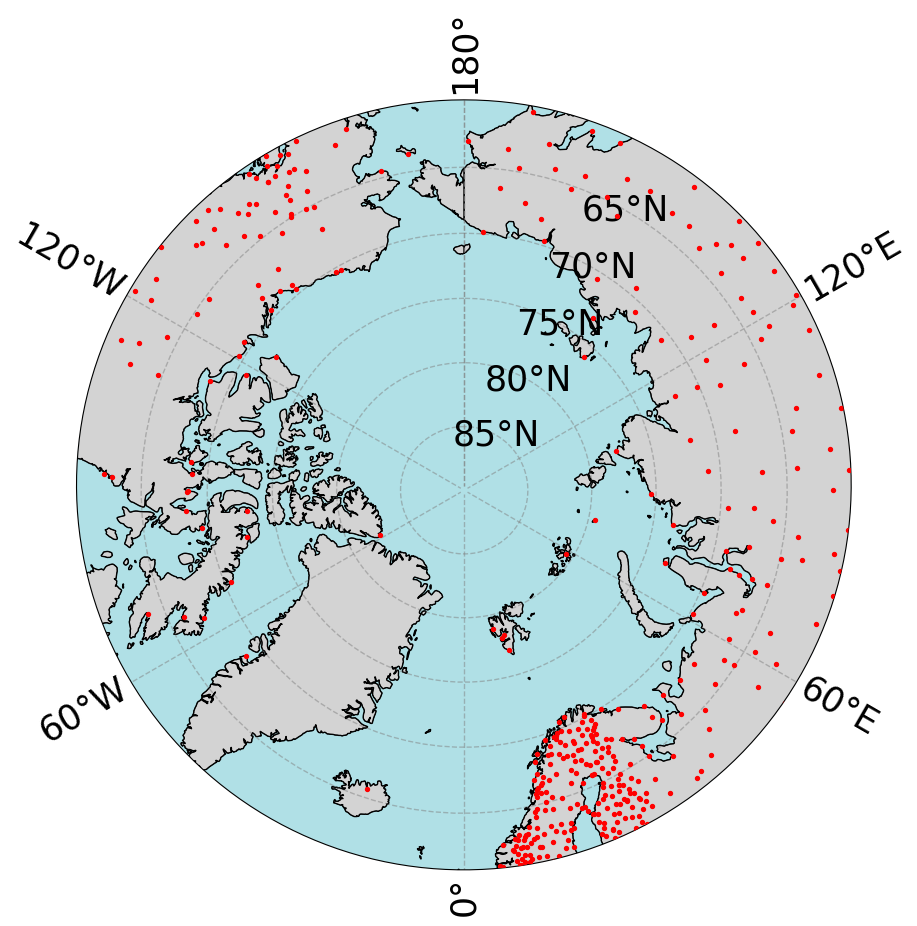

Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/Insitu/Stations_QC_passed_SWE_Tair_1988_2022.png


In [7]:
def wrap_lon180(lon):
    lon = float(lon)
    return ((lon + 180) % 360) - 180

# Read the file containing all valid station pairs (1988-2022)
cp = cpuserver_data_FP
save_dir = f"{cp}/personal_data/project_snow/NH_SWE/GSOD_overlap"
start_year, end_year = 1988, 2022

all_fp = os.path.join(save_dir, f"NH_SWE_GSOD_overlap_ALL_{start_year}_{end_year}.csv")
all_out = pd.read_csv(all_fp)

# North of 60N (Already filtered in the previous section, but to make sure) 
all_out = all_out[all_out["original_GSOD_lat"] >= 60].copy()

# Unique NH-SWE stations that appear at least once during the 35-year period
st_any = (
    all_out[["NHSWE_station_number", "original_NHSWE_lat", "original_NHSWE_lon"]]
    .drop_duplicates()
    .rename(columns={"original_NHSWE_lat": "lat", "original_NHSWE_lon": "lon"})
    .copy()
)
st_any["lon_w"] = st_any["lon"].apply(wrap_lon180)
print("Number of unique NH-SWE stations:", len(st_any))

# Save figure
fig, ax = plot_Northpole_stations_with_coords(
    pts_all=st_any[["lon_w", "lat"]],
    pts_highlight=None,
    title="",
    north_of=60,
    s_all=8,
    s_high=20,
    c_all="red",
    c_high="red",
    lon_col="lon_w",
    lat_col="lat",
    lon_grid_interval=60,
    lat_grid_interval=5,
    draw_grid_labels=True
)

out_dir = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Insitu"
os.makedirs(out_dir, exist_ok=True)

out_png = os.path.join(out_dir, "Stations_QC_passed_SWE_Tair_1988_2022.png")

fig.savefig(out_png, dpi=300, bbox_inches="tight", pad_inches=0.05)
print("Saved:", out_png)


## MOD Calculation Using In Situ SWE and Air Temperature

This section describes the derivation of melt onset date (MOD) using in situ SWE and air temperature ($T_{\mathrm{air}}$).  
Because a standardized method for directly estimating MOD and MED from combined SWE and $T_{\mathrm{air}}$ observations has not been well established, a rule-based operational definition was adopted in this study.

For MOD, both SWE and $T_{\mathrm{air}}$ were jointly considered. A 3-day moving window was applied to the annual time series, and the in situ MOD was defined as the first day that satisfies all of the following conditions:

1. The 3-day mean $T_{\mathrm{air}}$ exceeds 3 °C.  
2. SWE within the same 3-day window shows a strictly decreasing trend.  
3. SWE values for all three days are greater than zero.  

To avoid detecting unrealistically early MOD, additional quality control was applied.

In [8]:
def get_insitu_MOD_3day(
    df_year,
    swe_col="SWE",
    tair_col="Tair (degrees celsius)",
    date_col="date",
    tair_thr=3.0,
):
    df = df_year.sort_values(date_col).reset_index(drop=True)

    swe = pd.to_numeric(df[swe_col], errors="coerce").to_numpy(float)
    tair = pd.to_numeric(df[tair_col], errors="coerce").to_numpy(float)
    dates = pd.to_datetime(df[date_col], errors="coerce")

    n = len(df)
    if n < 3:
        return np.nan

    for t in range(2, n):
        # explicit 3-day window: t-2, t-1, t
        swe3 = swe[t-2:t+1]
        tair3 = tair[t-2:t+1]

        if np.any(~np.isfinite(swe3)) or np.any(~np.isfinite(tair3)):
            continue

        # 1) Tair 3-day mean > threshold
        if np.mean(tair3) <= tair_thr:
            continue

        # 2) SWE strictly decreasing
        if not (swe3[0] > swe3[1] > swe3[2]):
            continue

        # 3) SWE all > 0
        if np.any(swe3 <= 0):
            continue

        # first day satisfying all → return DOY of t-2
        return int(dates.iloc[t-2].dayofyear)

    return np.nan


In [9]:
MOD_records = []

group_cols = ["NHSWE_station_number", "GSOD_station_number", "year"]

for keys, g in all_out.groupby(group_cols):
    nh_id, gsod_id, year = keys

    # Calculate MOD
    mod = get_insitu_MOD_3day(g)
    
    # QC: Too early MOD detection
    if not np.isfinite(mod) or mod < 30:
        continue
    
    # Read metadata common to each station-pair-year group using the first row
    meta = g.iloc[0]

    rec = meta.to_dict()   # Copy all columns

    # Overwrite / Add MOD
    rec["MOD_DOY"] = mod

    rec.pop("date", None)
    rec.pop("SWE", None)
    rec.pop("Tair (degrees celsius)", None)

    MOD_records.append(rec)

MOD_df = pd.DataFrame(MOD_records)

# Print how many in situ MOD points are available
print(f"Number of in situ MOD points: {len(MOD_df)}")


Number of in situ MOD points: 4330


### Averaging In Situ MOD onto a 25 km Grid and save it with nc file

Since MOD was derived at station locations, it must be spatially aggregated to enable comparison with gridded datasets such as 25 km $\Delta T_b$ and other variables.  
To achieve this, station-based MOD values were resampled onto a 25 km grid, and all stations falling within each grid cell were averaged.

In [10]:
def wrap_lon_to_grid(lon, lon_axis):
    lon = np.asarray(lon, dtype=float)
    grid_min = float(np.nanmin(lon_axis))
    grid_max = float(np.nanmax(lon_axis))
    if grid_min >= 0 and grid_max > 180:  # grid is 0..360
        return lon % 360.0
    return ((lon + 180.0) % 360.0) - 180.0

def latlon_to_ij(sta_lat, sta_lon, lat_axis, lon_axis):
    sta_lat = np.asarray(sta_lat, dtype=float)
    sta_lon = wrap_lon_to_grid(sta_lon, lon_axis)

    dlat = float(np.median(np.diff(lat_axis)))
    dlon = float(np.median(np.diff(lon_axis)))
    lat0 = float(lat_axis[0])
    lon0 = float(lon_axis[0])

    i = np.rint((sta_lat - lat0) / dlat).astype(int)
    j = np.rint((sta_lon - lon0) / dlon).astype(int)

    i = np.clip(i, 0, len(lat_axis) - 1)
    j = np.clip(j, 0, len(lon_axis) - 1)
    return i, j


In [11]:
start_year, end_year = 1988, 2021
years = np.arange(start_year, end_year + 1)
ny = len(years)  # 34

MOD_df2 = MOD_df[(MOD_df["year"] >= start_year) & (MOD_df["year"] <= end_year)].copy()
MOD_df2 = MOD_df2[np.isfinite(MOD_df2["MOD_DOY"])].copy()

# Create grids and cut the latitude from north of 60N
domain_lon, domain_lat = hGrid.generate_lon_lat_eqdgrid(0.25)
domain_lat_60N = domain_lat[domain_lat[:,0] >= 60]
domain_lon_60N = domain_lon[domain_lat[:,0] >= 60]

print(ny)
print(np.shape(domain_lat_60N))
print(np.shape(domain_lon_60N))

H, W = domain_lat_60N.shape
lat_axis = domain_lat_60N[:, 0].astype(float)   # (120,)
lon_axis = domain_lon_60N[0, :].astype(float)   # (1440,)

print(lat_axis)
print(lon_axis)


MOD_df2["i"], MOD_df2["j"] = latlon_to_ij(
    MOD_df2["original_NHSWE_lat"].values,
    MOD_df2["original_NHSWE_lon"].values,
    lat_axis, lon_axis
)
MOD_df2["yi"] = (MOD_df2["year"].values.astype(int) - start_year).astype(int)

MOD_sum = np.zeros((H, W, ny), dtype=np.float64)
MOD_cnt = np.zeros((H, W, ny), dtype=np.int32)

ii = MOD_df2["i"].to_numpy(int)
jj = MOD_df2["j"].to_numpy(int)
yy = MOD_df2["yi"].to_numpy(int)
vv = MOD_df2["MOD_DOY"].to_numpy(float)

np.add.at(MOD_sum, (ii, jj, yy), vv)
np.add.at(MOD_cnt, (ii, jj, yy), 1)

MOD_grid = MOD_sum / np.where(MOD_cnt == 0, np.nan, MOD_cnt)
MOD_grid = MOD_grid.astype(np.float32)  # (120,1440,34)

# Save the averaged in situ MOD to a netCDF file
out_nc = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Insitu/Insitu_MOD_1988_2021_north60.nc"

with nc.Dataset(out_nc, "w") as ds:
    ds.createDimension("lat", H)
    ds.createDimension("lon", W)
    ds.createDimension("year", ny)

    vlat = ds.createVariable("lat", "f4", ("lat",))
    vlon = ds.createVariable("lon", "f4", ("lon",))
    vyr  = ds.createVariable("year", "i4", ("year",))

    vlat[:] = lat_axis
    vlon[:] = lon_axis
    vyr[:]  = years

    vmod = ds.createVariable("MOD_DOY", "f4", ("lat", "lon", "year"), zlib=True, complevel=4, fill_value=np.float32(np.nan))
    vcnt = ds.createVariable("n_station", "i4", ("lat", "lon", "year"), zlib=True, complevel=4)

    vmod[:, :, :] = MOD_grid
    vcnt[:, :, :] = MOD_cnt

    ds.title = "Station-derived MOD mapped to 0.25-degree grid north of 60N"
    ds.note  = "MOD_DOY is averaged within each (lat,lon,year) cell when multiple stations fall into the same grid cell."

print("The in situ MOD is saved as a netCDF file.")


34
(120, 1440)
(120, 1440)
[89.875 89.625 89.375 89.125 88.875 88.625 88.375 88.125 87.875 87.625
 87.375 87.125 86.875 86.625 86.375 86.125 85.875 85.625 85.375 85.125
 84.875 84.625 84.375 84.125 83.875 83.625 83.375 83.125 82.875 82.625
 82.375 82.125 81.875 81.625 81.375 81.125 80.875 80.625 80.375 80.125
 79.875 79.625 79.375 79.125 78.875 78.625 78.375 78.125 77.875 77.625
 77.375 77.125 76.875 76.625 76.375 76.125 75.875 75.625 75.375 75.125
 74.875 74.625 74.375 74.125 73.875 73.625 73.375 73.125 72.875 72.625
 72.375 72.125 71.875 71.625 71.375 71.125 70.875 70.625 70.375 70.125
 69.875 69.625 69.375 69.125 68.875 68.625 68.375 68.125 67.875 67.625
 67.375 67.125 66.875 66.625 66.375 66.125 65.875 65.625 65.375 65.125
 64.875 64.625 64.375 64.125 63.875 63.625 63.375 63.125 62.875 62.625
 62.375 62.125 61.875 61.625 61.375 61.125 60.875 60.625 60.375 60.125]
[-179.875 -179.625 -179.375 ...  179.375  179.625  179.875]
The in situ MOD is saved as a netCDF file.


## MED Calculation Using In Situ SWE

This section describes the derivation of the melt end date (MED) using in situ SWE observations. Unlike MOD, MED was determined solely based on SWE.

All consecutive zero-SWE periods within the analysis window (DOY 1–250) were first identified. Among these, only periods with a duration of at least seven consecutive days were considered as valid snow-off conditions. The in situ MED was then defined as the first day of the latest valid zero-SWE period.

This definition assumes that the disappearance of the seasonal snowpack is best represented by the final depletion of the main snow accumulation. Therefore, short-lived or intermittent snowfall events occurring after the primary melt period were ignored unless they resulted in a new zero-SWE period that also satisfied the minimum duration criterion.

In [12]:
def get_insitu_MED_zero_run(
    df_year,
    swe_col="SWE",
    date_col="date",
    max_doy=250,
    zero_thr=0.0,
    min_consec_zeros=7,  
):
    df = df_year.copy()
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.sort_values(date_col).reset_index(drop=True)

    # Compute DOY and restrict to the analysis window
    doy = df[date_col].dt.dayofyear.to_numpy()
    swe = pd.to_numeric(df[swe_col], errors="coerce").to_numpy(float)

    m = np.isfinite(doy) & (doy >= 1) & (doy <= max_doy)
    if not np.any(m):
        return np.nan

    doy = doy[m].astype(int)
    swe = swe[m]

    # Resort by DOY to handle potential missing or duplicate dates
    order = np.argsort(doy)
    doy = doy[order]
    swe = swe[order]

    # Identify zero-SWE days (NaNs are treated as False, to break consecutive sequences)
    is_zero = np.isfinite(swe) & (swe <= zero_thr)

    # Find all consecutive zero-SWE runs
    valid_run_starts = []
    run_start = None

    for i, flag in enumerate(is_zero):
        if flag:
            if run_start is None:
                run_start = i
        else:
            if run_start is not None:
                run_len = i - run_start
                if run_len >= min_consec_zeros:
                    valid_run_starts.append(run_start)
                run_start = None

    # Handle the case where the series ends during a zero run
    if run_start is not None:
        run_len = len(is_zero) - run_start
        if run_len >= min_consec_zeros:
            valid_run_starts.append(run_start)

    if not valid_run_starts:
        return np.nan

    # Select the latest valid zero-SWE run
    return int(doy[valid_run_starts[-1]])

In [13]:
MED_records = []

group_cols = ["NHSWE_station_number", "GSOD_station_number", "year"]

for keys, g in all_out.groupby(group_cols):
    nh_id, gsod_id, year = keys

    # Calculate MED
    med = get_insitu_MED_zero_run(
        g,
        swe_col="SWE",
        date_col="date",
        max_doy=250,
        zero_thr=0.0,
        min_consec_zeros=7,   
    )

    meta = g.iloc[0]
    rec = meta.to_dict()

    rec["MED_DOY"] = med

    # Remove columns that are not representative values 
    rec.pop("date", None)
    rec.pop("SWE", None)
    rec.pop("Tair (degrees celsius)", None)

    MED_records.append(rec)

MED_df = pd.DataFrame(MED_records)

print(f"Number of in situ MED points: {len(MED_df)}")


Number of in situ MED points: 5446


### Averaging In Situ MED onto a 25 km Grid and save it with nc file

Since MED was derived at station locations, it must be spatially aggregated to enable comparison with gridded datasets such as 25 km $\Delta T_b$ and other variables.  
To achieve this, station-based MED values were resampled onto a 25 km grid, and all stations falling within each grid cell were averaged.

In [14]:
start_year, end_year = 1988, 2021
years = np.arange(start_year, end_year + 1)
ny = len(years)  # 34

MED_df2 = MED_df[(MED_df["year"] >= start_year) & (MED_df["year"] <= end_year)].copy()
MED_df2 = MED_df2[np.isfinite(MED_df2["MED_DOY"])].copy()

# Create grids and cut the latitude from north of 60N
domain_lon, domain_lat = hGrid.generate_lon_lat_eqdgrid(0.25)
domain_lat_60N = domain_lat[domain_lat[:,0] >= 60]
domain_lon_60N = domain_lon[domain_lat[:,0] >= 60]

print(ny)
print(np.shape(domain_lat_60N))
print(np.shape(domain_lon_60N))

H, W = domain_lat_60N.shape
lat_axis = domain_lat_60N[:, 0].astype(float)   # (120,)
lon_axis = domain_lon_60N[0, :].astype(float)   # (1440,)

print(lat_axis)
print(lon_axis)

MED_df2["i"], MED_df2["j"] = latlon_to_ij(
    MED_df2["original_NHSWE_lat"].values,
    MED_df2["original_NHSWE_lon"].values,
    lat_axis, lon_axis
)
MED_df2["yi"] = (MED_df2["year"].values.astype(int) - start_year).astype(int)

MED_sum = np.zeros((H, W, ny), dtype=np.float64)
MED_cnt = np.zeros((H, W, ny), dtype=np.int32)

ii = MED_df2["i"].to_numpy(int)
jj = MED_df2["j"].to_numpy(int)
yy = MED_df2["yi"].to_numpy(int)
vv = MED_df2["MED_DOY"].to_numpy(float)

np.add.at(MED_sum, (ii, jj, yy), vv)
np.add.at(MED_cnt, (ii, jj, yy), 1)

MED_grid = MED_sum / np.where(MED_cnt == 0, np.nan, MED_cnt)
MED_grid = MED_grid.astype(np.float32)  # (120,1440,34)


# Save the averaged in situ MED to a netCDF file
out_nc = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Insitu/Insitu_MED_1988_2021_north60.nc"

with nc.Dataset(out_nc, "w") as ds:
    ds.createDimension("lat", H)
    ds.createDimension("lon", W)
    ds.createDimension("year", ny)

    vlat = ds.createVariable("lat", "f4", ("lat",))
    vlon = ds.createVariable("lon", "f4", ("lon",))
    vyr  = ds.createVariable("year", "i4", ("year",))

    vlat[:] = lat_axis
    vlon[:] = lon_axis
    vyr[:]  = years

    vmod = ds.createVariable("MED_DOY", "f4", ("lat", "lon", "year"), zlib=True, complevel=4, fill_value=np.float32(np.nan))
    vcnt = ds.createVariable("n_station", "i4", ("lat", "lon", "year"), zlib=True, complevel=4)

    vmod[:, :, :] = MED_grid
    vcnt[:, :, :] = MED_cnt

    ds.title = "Station-derived MED mapped to 0.25-degree grid north of 60N"
    ds.note  = "MED_DOY is averaged within each (lat,lon,year) cell when multiple stations fall into the same grid cell."
    
print("The in situ MED is saved as a netCDF file.")

34
(120, 1440)
(120, 1440)
[89.875 89.625 89.375 89.125 88.875 88.625 88.375 88.125 87.875 87.625
 87.375 87.125 86.875 86.625 86.375 86.125 85.875 85.625 85.375 85.125
 84.875 84.625 84.375 84.125 83.875 83.625 83.375 83.125 82.875 82.625
 82.375 82.125 81.875 81.625 81.375 81.125 80.875 80.625 80.375 80.125
 79.875 79.625 79.375 79.125 78.875 78.625 78.375 78.125 77.875 77.625
 77.375 77.125 76.875 76.625 76.375 76.125 75.875 75.625 75.375 75.125
 74.875 74.625 74.375 74.125 73.875 73.625 73.375 73.125 72.875 72.625
 72.375 72.125 71.875 71.625 71.375 71.125 70.875 70.625 70.375 70.125
 69.875 69.625 69.375 69.125 68.875 68.625 68.375 68.125 67.875 67.625
 67.375 67.125 66.875 66.625 66.375 66.125 65.875 65.625 65.375 65.125
 64.875 64.625 64.375 64.125 63.875 63.625 63.375 63.125 62.875 62.625
 62.375 62.125 61.875 61.625 61.375 61.125 60.875 60.625 60.375 60.125]
[-179.875 -179.625 -179.375 ...  179.375  179.625  179.875]
The in situ MED is saved as a netCDF file.


## Visualization of In Situ Melt Dates

In situ MOD and MED are plotted to examine the resulting spatial patterns.

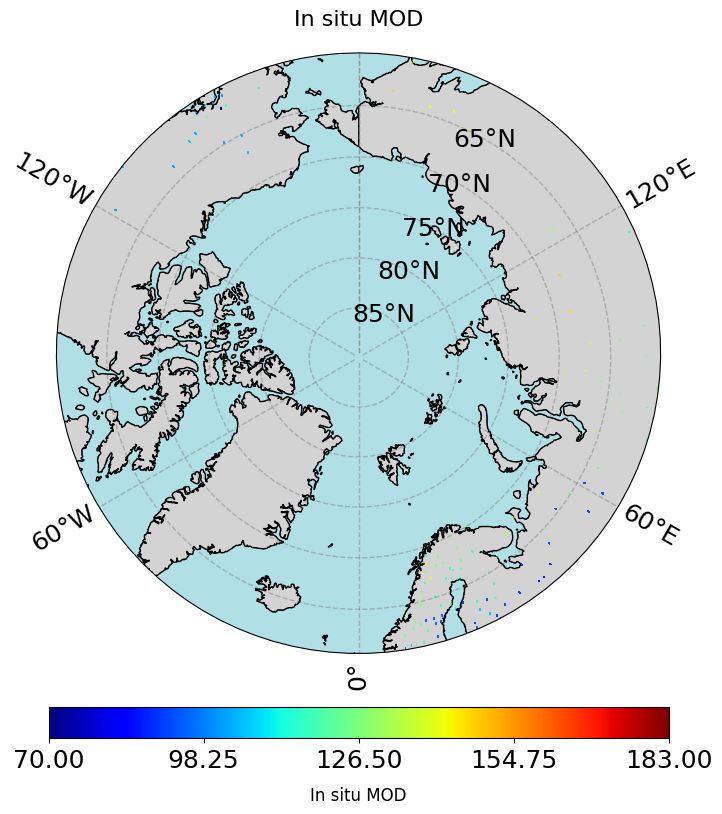

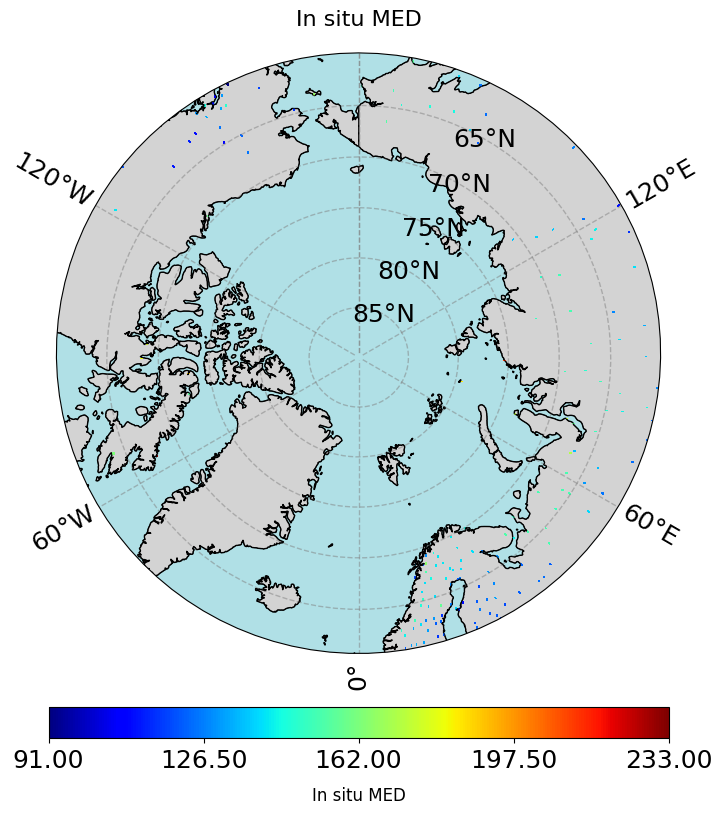

(<Figure size 1000x1000 with 2 Axes>,
 <GeoAxes: title={'center': 'In situ MED'}>)

In [15]:
insitu_MOD_nc = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Insitu/Insitu_MOD_1988_2021_north60.nc"
insitu_MED_nc = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Insitu/Insitu_MED_1988_2021_north60.nc"

with nc.Dataset(insitu_MOD_nc, "r") as ds:
    lat_MOD = ds["lat"][:]
    lon_MOD = ds["lon"][:]
    Insitu_MOD = ds["MOD_DOY"][:, :, 0] # # 1988 in situ MOD

with nc.Dataset(insitu_MED_nc, "r") as ds:
    lat_MED = ds["lat"][:]
    lon_MED = ds["lon"][:]
    Insitu_MED = ds["MED_DOY"][:, :, 0] # # 1988 in situ MED

lon_MOD, lat_MOD = np.meshgrid(lon_MOD, lat_MOD)
lon_MED, lat_MED = np.meshgrid(lon_MED, lat_MED)

mod_min = np.nanmin(Insitu_MOD)
mod_med = np.nanmedian(Insitu_MOD)
mod_max = np.nanmax(Insitu_MOD)

med_min = np.nanmin(Insitu_MED)
med_med = np.nanmedian(Insitu_MED)
med_max = np.nanmax(Insitu_MED)

mod_vcenter = mod_med if (mod_min < mod_med < mod_max) else None
med_vcenter = med_med if (med_min < med_med < med_max) else None

plot_Northpole(
    lon_MOD, lat_MOD, Insitu_MOD,
    "In situ MOD", "jet",
    vmin=mod_min, vmax=mod_max, vcenter=mod_vcenter
)

plot_Northpole(
    lon_MED, lat_MED, Insitu_MED,
    "In situ MED", "jet",
    vmin=med_min, vmax=med_max, vcenter=med_vcenter
)
